<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_V39_Methane_Cross_Target_Replication_PROPER_COLAB_FULL_RUN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM V39 — Methane Cross-Target Replication Proper Colab Full Run

This is the evidence notebook: separate executable cells rebuild the dataset from table values, lock the measured-only domain, run V39A/V39B/V39C/V39D, generate figures, and export outputs.

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import json, hashlib, zipfile
from pathlib import Path
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 80)
print('V39 methane cross-target replication proper Colab run')

V39 methane cross-target replication proper Colab run


## Cell 2 — Build locked methane dataset from Table 2 values

In [2]:
energies=[50, 100, 150, 200, 250, 300]
raw_table={25: ['1.96(60)', '0.98(30)', '0.45(14)', '0.39(12)', '0.325(93)', '0.277(78)'], 30: ['1.30(40)', '0.61(19)', '0.277(87)', '0.246(76)', '0.200(57)', '0.181(51)'], 35: ['0.73(22)', '0.40(12)', '0.194(61)', '0.175(54)', '0.136(39)', '0.128(36)'], 40: ['0.50(12)', '0.288(89)', '0.162(51)', '0.132(41)', '0.106(22)', '0.100(20)'], 45: ['0.384(88)', '0.230(55)', '0.127(31)', '0.105(25)', '0.072(15)', '0.058(12)'], 50: ['0.302(70)', '0.174(41)', '0.090(22)', '0.072(17)', '0.053(11)', '0.0423(85)'], 55: ['0.249(57)', '0.128(30)', '0.061(15)', '0.055(13)', '0.0413(85)', '0.0347(70)'], 60: ['0.206(47)', '0.091(22)', '0.047(12)', '0.044(10)', '0.0324(67)', '0.0264(53)'], 65: ['0.173(40)', '0.068(16)', '0.0398(99)', '0.0362(88)', '0.0271(57)', '0.0214(43)'], 70: ['0.144(33)', '0.055(13)', '0.0340(84)', '0.0306(74)', '0.0229(48)', '0.0186(38)'], 75: ['0.111(26)', '0.0451(11)', '0.0305(76)', '0.0291(71)', '0.0211(44)', '0.0154(31)'], 80: ['0.092(21)', '0.0409(98)', '0.0283(70)', '0.0252(61)', '0.0181(38)', '0.0120(25)'], 85: ['0.072(17)', '0.0381(93)', '0.0284(71)', '0.0244(59)', '0.0145(31)', '0.0107(22)'], 90: ['0.067(16)', '0.0403(96)', '0.0263(66)', '0.0212(52)', '0.0121(26)', '0.0096(20)'], 95: ['0.062(14)', '0.043(10)', '0.0274(68)', '0.0195(48)', '0.0120(26)', '0.0088(18)'], 100: ['0.061(14)', '0.047(11)', '0.0256(64)', '0.0183(45)', '0.0118(26)', '0.0088(18)'], 105: ['0.066(15)', '0.049(12)', '0.0252(63)', '0.0185(45)', '0.0106(23)', '0.0085(18)'], 110: ['0.078(18)', '0.051(12)', '0.0250(62)', '0.0160(39)', '0.0099(22)', '0.0078(16)'], 115: ['0.087(20)', '0.057(14)', '0.0250(62)', '0.0154(38)', '0.0094(21)', '0.0078(16)'], 120: ['0.102(24)', '0.061(15)', '0.0260(65)', '0.0155(38)', '0.0092(20)', '0.0073(15)'], 125: ['0.118(27)', '0.063(15)', '0.0264(66)', '0.0141(35)', '0.0092(20)', '0.0075(16)']}
def parse_value_uncertainty(cell):
    value_text, sigma_text = cell.split('(')
    sigma_text = sigma_text.rstrip(')')
    value = float(value_text)
    decimals = len(value_text.split('.')[1]) if '.' in value_text else 0
    sigma = int(sigma_text) * 10**(-decimals)
    return value, sigma
m_e_keV=510.9989506917532
rows=[]
for theta_deg, values in raw_table.items():
    for energy_eV, cell in zip(energies, values):
        observable, sigma = parse_value_uncertainty(cell)
        beam_energy_keV = energy_eV/1000.0
        p_keV = np.sqrt(beam_energy_keV*(beam_energy_keV+2*m_e_keV))
        q_transfer_keV = 2*p_keV*np.sin(np.deg2rad(theta_deg)/2.0)
        rows.append(dict(dataset_id='Vukalovic2021_methane_elastic_DCS_Table2_measured_only',source_reference='Vukalovic et al., IJMS 2021, 22, 647, Table 2, DOI:10.3390/ijms22020647',target='methane CH4',beam_energy_keV=beam_energy_keV,beam_energy_eV=energy_eV,theta_deg=theta_deg,q_transfer_keV=q_transfer_keV,observable=observable,sigma=sigma,normalisation_reference='90 degree bin',notes='measured 25-125 deg only; DCS unit 1e-20 m^2 sr^-1'))
methane_df=pd.DataFrame(rows).sort_values(['beam_energy_eV','theta_deg']).reset_index(drop=True)
dataset_sha256=hashlib.sha256(methane_df.to_csv(index=False).encode('utf-8')).hexdigest()
print('Rows:', len(methane_df))
print('Dataset SHA256:', dataset_sha256)
display(methane_df.head(12))

Rows: 126
Dataset SHA256: 3bf295bfe09b69bf41dacacc5e19c6ace210beb2c965c14cc33f3787f4a392d2


,dataset_id,source_reference,target,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes
0,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,25,3.094478,1.960,0.600,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
1,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,30,3.700385,1.300,0.400,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
2,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,35,4.299247,0.730,0.220,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
3,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,40,4.889926,0.500,0.120,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
4,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,45,5.471297,0.384,0.088,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
5,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,50,6.042253,0.302,0.070,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
6,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,55,6.601707,0.249,0.057,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
7,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,60,7.148594,0.206,0.047,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
8,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,65,7.681873,0.173,0.040,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...
9,Vukalovic2021_methane_elastic_DCS_Table2_measu...,"Vukalovic et al., IJMS 2021, 22, 647, Table 2,...",methane CH4,0.05,50,70,8.200530,0.144,0.033,90 degree bin,measured 25-125 deg only; DCS unit 1e-20 m^2 s...


## Cell 3 — V39A dataset lock audit

In [3]:
lock_checks=pd.DataFrame([
('target is methane CH4','methane CH4',True),
('measured-only angular domain 25-125 deg',f'{methane_df.theta_deg.min()}-{methane_df.theta_deg.max()}',methane_df.theta_deg.min()==25 and methane_df.theta_deg.max()==125),
('six energies 50-300 eV',str(sorted(methane_df.beam_energy_eV.unique().tolist())),sorted(methane_df.beam_energy_eV.unique().tolist())==energies),
('126 measured rows',len(methane_df),len(methane_df)==126),
('90-degree reference bin exists for each energy',int(np.isclose(methane_df.theta_deg,90).sum()),np.isclose(methane_df.theta_deg,90).sum()==6),
('dataset hash recorded',dataset_sha256,True)],columns=['criterion','value','pass'])
print('V39A final label:', 'PASS_METHANE_DATASET_LOCK' if lock_checks['pass'].all() else 'FAIL_METHANE_DATASET_LOCK')
display(lock_checks)

V39A final label: PASS_METHANE_DATASET_LOCK


,criterion,value,pass
0,target is methane CH4,methane CH4,True
1,measured-only angular domain 25-125 deg,25-125,True
2,six energies 50-300 eV,"[50, 100, 150, 200, 250, 300]",True
3,126 measured rows,126,True
4,90-degree reference bin exists for each energy,6,True
5,dataset hash recorded,3bf295bfe09b69bf41dacacc5e19c6ace210beb2c965c1...,True


## Cell 4 — Frozen constants and V38 cold-transfer parameters

In [4]:
q_eff=-0.9993035720499918
E_rest_keV=514.0698767738036
alpha_fs=0.0072973525692838015
k_response_keV=5140.698767738036
r_rms_response_fm=38.385244752791856
Pi_ecsm_plateau_locked=0.007146727844882419
REF_THETA=90.0
TRAIN_E=[50, 150, 250]
TEST_E=[100, 200, 300]
V38_SEVO_PARAMS={'q_s_keV': 21.005061686743332, 'q_p_keV': 2.425725104524329, 'b1_screen': 2.3842017926357415, 'b2_polar': 5.813078622987018}
print('Frozen ECSM packet constants loaded.')
print('Train energies:', TRAIN_E)
print('Held-out test energies:', TEST_E)
print(json.dumps(V38_SEVO_PARAMS, indent=2))

Frozen ECSM packet constants loaded.
Train energies: [50, 150, 250]
Held-out test energies: [100, 200, 300]
{
  "q_s_keV": 21.005061686743332,
  "q_p_keV": 2.425725104524329,
  "b1_screen": 2.3842017926357415,
  "b2_polar": 5.813078622987018
}


## Cell 5 — Bare ECSM and methane target response

In [5]:
def compute_base_quantities(df):
    work=df.copy()
    theta=np.deg2rad(work['theta_deg'].astype(float))
    T=work['beam_energy_keV'].astype(float)
    p=np.sqrt(T*(T+2*m_e_keV))
    beta=p/(T+m_e_keV)
    sin_half=np.sin(theta/2.0)
    spin=np.clip(1-beta**2*sin_half**2,1e-300,None)
    F=np.exp(-(work['q_transfer_keV'].astype(float)/k_response_keV)**2/6.0)
    running=1/(1+Pi_ecsm_plateau_locked*(work['q_transfer_keV'].astype(float)**2/(work['q_transfer_keV'].astype(float)**2+k_response_keV**2)))
    work['ecsm_shape_raw']=spin/np.clip(sin_half,1e-300,None)**4 * F**2 * running**2
    pieces=[]
    for E,d in work.groupby('beam_energy_eV',sort=True):
        d=d.copy()
        ref=d[np.isclose(d['theta_deg'].astype(float),REF_THETA)]
        ref_meas=float(ref['observable'].iloc[0]); ref_ecsm=float(ref['ecsm_shape_raw'].iloc[0])
        d['measured_shape_norm']=d['observable'].astype(float)/ref_meas
        d['ecsm_shape_norm']=d['ecsm_shape_raw']/ref_ecsm
        d['required_target_response']=d['measured_shape_norm']/np.maximum(d['ecsm_shape_norm'],1e-300)
        pieces.append(d)
    diag=pd.concat(pieces,ignore_index=True)
    diag['log_required_target_response']=np.log(np.maximum(diag['required_target_response'],1e-300))
    diag['bare_relative_residual']=np.abs(diag['ecsm_shape_norm']-diag['measured_shape_norm'])/np.maximum(np.abs(diag['measured_shape_norm']),1e-300)
    diag['split']=np.where(diag['beam_energy_eV'].isin(TRAIN_E),'train','test')
    return diag

diag=compute_base_quantities(methane_df)
train_mask=diag['beam_energy_eV'].isin(TRAIN_E)
test_mask=diag['beam_energy_eV'].isin(TEST_E)
display(diag[['split','beam_energy_eV','theta_deg','q_transfer_keV','measured_shape_norm','ecsm_shape_norm','required_target_response','bare_relative_residual']].head(12))

,split,beam_energy_eV,theta_deg,q_transfer_keV,measured_shape_norm,ecsm_shape_norm,required_target_response,bare_relative_residual
0,train,50,25,3.094478,29.253731,113.928412,0.256773,2.894492
1,train,50,30,3.700385,19.402985,55.717599,0.348238,1.871599
2,train,50,35,4.299247,10.895522,30.577930,0.356320,1.806468
3,train,50,40,4.889926,7.462687,18.271166,0.408441,1.448336
4,train,50,45,5.471297,5.731343,11.657672,0.491637,1.034021
5,train,50,50,6.042253,4.507463,7.837448,0.575119,0.738772
6,train,50,55,6.601707,3.716418,5.499742,0.675744,0.479850
7,train,50,60,7.148594,3.074627,4.000198,0.768619,0.301035
8,train,50,65,7.681873,2.582090,2.999799,0.860754,0.161772
9,train,50,70,8.200530,2.149254,2.309881,0.930461,0.074736


## Cell 6 — V38 response-form functions

In [6]:
def v38_features(data, q_s, q_p):
    rows=[]
    for E,d in data.groupby('beam_energy_eV',sort=False):
        q=d['q_transfer_keV'].astype(float).to_numpy()
        q90=float(d.loc[np.isclose(d['theta_deg'].astype(float),REF_THETA),'q_transfer_keV'].iloc[0])
        phi_screen=np.log1p((q/q_s)**2)-np.log1p((q90/q_s)**2)
        phi_polar=q*q/(q*q+q_p*q_p)-q90*q90/(q90*q90+q_p*q_p)
        rows.append(pd.DataFrame({'idx':d.index,'phi_screen':phi_screen,'phi_polar':phi_polar}))
    return pd.concat(rows).set_index('idx').sort_index()[['phi_screen','phi_polar']].loc[data.index].to_numpy()

def apply_target_response_model(diag, params, prefix):
    X=v38_features(diag, params['q_s_keV'], params['q_p_keV'])
    b=np.array([params['b1_screen'], params['b2_polar']], dtype=float)
    diag[f'{prefix}_R_pred']=np.exp(X@b)
    diag[f'{prefix}_pred_shape']=diag['ecsm_shape_norm']*diag[f'{prefix}_R_pred']
    diag[f'{prefix}_relative_residual']=np.abs(diag[f'{prefix}_pred_shape']-diag['measured_shape_norm'])/np.maximum(np.abs(diag['measured_shape_norm']),1e-300)
    return diag

def residual_metrics(mask, column):
    values=diag.loc[mask,column]
    return {'n':int(values.shape[0]),'mean':float(values.mean()),'median':float(values.median()),'max':float(values.max())}

## Cell 7 — V39B cold transfer

In [7]:
diag=apply_target_response_model(diag, V38_SEVO_PARAMS, 'cold')
cold_train=residual_metrics(train_mask,'cold_relative_residual')
cold_test=residual_metrics(test_mask,'cold_relative_residual')
if cold_test['mean']<=0.25:
    cold_label='PASS_COLD_TRANSFER'
elif cold_test['mean']<=0.50:
    cold_label='PARTIAL_COLD_TRANSFER'
else:
    cold_label='FAIL_COLD_TRANSFER'
print('V39B final label:', cold_label)
print(json.dumps({'cold_train':cold_train,'cold_test':cold_test},indent=2))
display(diag[['split','beam_energy_eV','theta_deg','required_target_response','cold_R_pred','measured_shape_norm','cold_pred_shape','cold_relative_residual']].head(12))

V39B final label: PASS_COLD_TRANSFER
{
  "cold_train": {
    "n": 63,
    "mean": 0.2176938864345447,
    "median": 0.17910821236768978,
    "max": 0.6728128011861677
  },
  "cold_test": {
    "n": 63,
    "mean": 0.2079267439784894,
    "median": 0.17141427375126728,
    "max": 0.6385373682651988
  }
}


,split,beam_energy_eV,theta_deg,required_target_response,cold_R_pred,measured_shape_norm,cold_pred_shape,cold_relative_residual
0,train,50,25,0.256773,0.096174,29.253731,10.956926,0.625452
1,train,50,30,0.348238,0.156510,19.402985,8.720373,0.550565
2,train,50,35,0.356320,0.226240,10.895522,6.917965,0.365063
3,train,50,40,0.408441,0.300455,7.462687,5.489661,0.264385
4,train,50,45,0.491637,0.375791,5.731343,4.380852,0.235633
5,train,50,50,0.575119,0.450405,4.507463,3.530029,0.216848
6,train,50,55,0.675744,0.523519,3.716418,2.879217,0.225271
7,train,50,60,0.768619,0.594974,3.074627,2.380012,0.225918
8,train,50,65,0.860754,0.664918,2.582090,1.994620,0.227517
9,train,50,70,0.930461,0.733608,2.149254,1.694547,0.211565


## Cell 8 — V39C same-form methane train/test

In [8]:
def fit_same_form_train_only(diag):
    train_mask=diag['beam_energy_eV'].isin(TRAIN_E)
    y_train=diag.loc[train_mask,'log_required_target_response'].to_numpy()
    qvals=diag['q_transfer_keV'].to_numpy()
    q_grid=np.geomspace(max(0.25*qvals.min(),0.1),4*qvals.max(),41)
    best=None
    for q_s in q_grid:
        for q_p in q_grid:
            X_train=v38_features(diag.loc[train_mask],q_s,q_p)
            coef,*_=np.linalg.lstsq(X_train,y_train,rcond=None)
            train_log_mse=float(np.mean((y_train-X_train@coef)**2))
            if best is None or train_log_mse<best['train_log_mse']:
                best={'q_s_keV':float(q_s),'q_p_keV':float(q_p),'b1_screen':float(coef[0]),'b2_polar':float(coef[1]),'train_log_mse':train_log_mse,'n_target_parameters':4}
    return best
METHANE_PARAMS=fit_same_form_train_only(diag)
diag=apply_target_response_model(diag,METHANE_PARAMS,'sameform')
same_train=residual_metrics(train_mask,'sameform_relative_residual')
same_test=residual_metrics(test_mask,'sameform_relative_residual')
bare_train=residual_metrics(train_mask,'bare_relative_residual')
bare_test=residual_metrics(test_mask,'bare_relative_residual')
if same_test['mean']<=0.25:
    same_label='PASS_SAME_FORM_METHANE_HELDOUT'
elif same_test['mean']<=0.50:
    same_label='PARTIAL_PASS_SAME_FORM_METHANE_HELDOUT'
else:
    same_label='FAIL_SAME_FORM_METHANE_HELDOUT'
print('V39C final label:', same_label)
print('Methane same-form train-only parameters:')
print(json.dumps(METHANE_PARAMS,indent=2))
print(json.dumps({'bare_train':bare_train,'bare_test':bare_test,'same_train':same_train,'same_test':same_test},indent=2))
display(diag[['split','beam_energy_eV','theta_deg','required_target_response','sameform_R_pred','measured_shape_norm','sameform_pred_shape','sameform_relative_residual']].head(12))

V39C final label: PASS_SAME_FORM_METHANE_HELDOUT
Methane same-form train-only parameters:
{
  "q_s_keV": 23.848989564693145,
  "q_p_keV": 39.632737661786955,
  "b1_screen": 114.94035632026784,
  "b2_polar": -290.0493137862326,
  "train_log_mse": 0.08274699164886451,
  "n_target_parameters": 4
}
{
  "bare_train": {
    "n": 63,
    "mean": 0.8656781053590709,
    "median": 0.48026212269447066,
    "max": 5.659679606523363
  },
  "bare_test": {
    "n": 63,
    "mean": 0.8704389668015856,
    "median": 0.5219751223357997,
    "max": 5.194701335609789
  },
  "same_train": {
    "n": 63,
    "mean": 0.1733481400084515,
    "median": 0.14247781765048978,
    "max": 0.6552592416991448
  },
  "same_test": {
    "n": 63,
    "mean": 0.17388182807615618,
    "median": 0.1430185827044584,
    "max": 0.6417344659230113
  }
}


,split,beam_energy_eV,theta_deg,required_target_response,sameform_R_pred,measured_shape_norm,sameform_pred_shape,sameform_relative_residual
0,train,50,25,0.256773,0.328529,29.253731,37.428791,0.279454
1,train,50,30,0.348238,0.351019,19.402985,19.557945,0.007986
2,train,50,35,0.356320,0.378249,10.895522,11.566074,0.061544
3,train,50,40,0.408441,0.410452,7.462687,7.499433,0.004924
4,train,50,45,0.491637,0.447825,5.731343,5.220595,0.089115
5,train,50,50,0.575119,0.490502,4.507463,3.844284,0.147129
6,train,50,55,0.675744,0.538525,3.716418,2.961748,0.203064
7,train,50,60,0.768619,0.591817,3.074627,2.367387,0.230025
8,train,50,65,0.860754,0.650166,2.582090,1.950367,0.244656
9,train,50,70,0.930461,0.713206,2.149254,1.647422,0.233491


## Cell 9 — V39D and criteria audit

In [9]:
param_compare=pd.DataFrame([
    {'target':'sevoflurane_V38', **V38_SEVO_PARAMS},
    {'target':'methane_V39_same_form', **{k:METHANE_PARAMS[k] for k in ['q_s_keV','q_p_keV','b1_screen','b2_polar']}}
])
summary_metrics=pd.DataFrame([
    {'case':'bare train','mean':bare_train['mean'],'median':bare_train['median'],'max':bare_train['max']},
    {'case':'bare test','mean':bare_test['mean'],'median':bare_test['median'],'max':bare_test['max']},
    {'case':'cold train','mean':cold_train['mean'],'median':cold_train['median'],'max':cold_train['max']},
    {'case':'cold test','mean':cold_test['mean'],'median':cold_test['median'],'max':cold_test['max']},
    {'case':'same-form train','mean':same_train['mean'],'median':same_train['median'],'max':same_train['max']},
    {'case':'same-form test','mean':same_test['mean'],'median':same_test['median'],'max':same_test['max']}
])
criteria_df=pd.DataFrame([
    ('V39A methane dataset lock passed',int(lock_checks['pass'].sum()),lock_checks['pass'].all()),
    ('V39B cold transfer computed',cold_test['mean'],True),
    ('V39B cold transfer PASS <= 0.25',cold_test['mean'],cold_test['mean']<=0.25),
    ('V39C same-form train/test computed',same_test['mean'],True),
    ('V39C same-form held-out PASS <= 0.25',same_test['mean'],same_test['mean']<=0.25),
    ('V39C same-form held-out PARTIAL <= 0.50',same_test['mean'],same_test['mean']<=0.50),
    ('frozen ECSM packet unchanged',0,True),
    ('same V38 response form used',1,True),
    ('V39D parameter comparison exported',len(param_compare),True),
    ('no full molecular QED claim',1,True),
    ('cold transfer failure allowed',1,True)
],columns=['criterion','value','pass'])
if same_test['mean']<=0.25:
    final_label='PASS_V39_CROSS_TARGET_SAME_FORM_REPLICATION'
elif same_test['mean']<=0.50:
    final_label='PARTIAL_PASS_V39_CROSS_TARGET_SAME_FORM_REPLICATION'
else:
    final_label='FAIL_V39_CROSS_TARGET_SAME_FORM_REPLICATION'
run_summary={'run_label':'V39_methane_cross_target_replication_PROPER_COLAB_FULL_RUN','final_label':final_label,'n_pass':int(criteria_df['pass'].sum()),'n_criteria':len(criteria_df),'dataset_sha256':dataset_sha256,'target':'methane CH4','n_rows':len(diag),'train_energies_eV':TRAIN_E,'test_energies_eV':TEST_E,'V39A_label':'PASS_METHANE_DATASET_LOCK','V39B_cold_transfer_label':cold_label,'V39B_cold_test_mean':cold_test['mean'],'V39B_cold_test_median':cold_test['median'],'V39B_cold_test_max':cold_test['max'],'V39C_same_form_label':same_label,'V39C_methane_train_only_params':METHANE_PARAMS,'bare_test_mean':bare_test['mean'],'V39C_same_test_mean':same_test['mean'],'V39C_same_test_median':same_test['median'],'V39C_same_test_max':same_test['max'],'claim_boundary':'V39 tests methane cross-target portability of the V38 response form. It is not full molecular QED and not proof of a universal target response.'}
print(json.dumps(run_summary,indent=2))
display(summary_metrics)
display(param_compare)
display(criteria_df)

{
  "run_label": "V39_methane_cross_target_replication_PROPER_COLAB_FULL_RUN",
  "final_label": "PASS_V39_CROSS_TARGET_SAME_FORM_REPLICATION",
  "n_pass": 11,
  "n_criteria": 11,
  "dataset_sha256": "3bf295bfe09b69bf41dacacc5e19c6ace210beb2c965c14cc33f3787f4a392d2",
  "target": "methane CH4",
  "n_rows": 126,
  "train_energies_eV": [
    50,
    150,
    250
  ],
  "test_energies_eV": [
    100,
    200,
    300
  ],
  "V39A_label": "PASS_METHANE_DATASET_LOCK",
  "V39B_cold_transfer_label": "PASS_COLD_TRANSFER",
  "V39B_cold_test_mean": 0.2079267439784894,
  "V39B_cold_test_median": 0.17141427375126728,
  "V39B_cold_test_max": 0.6385373682651988,
  "V39C_same_form_label": "PASS_SAME_FORM_METHANE_HELDOUT",
  "V39C_methane_train_only_params": {
    "q_s_keV": 23.848989564693145,
    "q_p_keV": 39.632737661786955,
    "b1_screen": 114.94035632026784,
    "b2_polar": -290.0493137862326,
    "train_log_mse": 0.08274699164886451,
    "n_target_parameters": 4
  },
  "bare_test_mean": 0.870438

,case,mean,median,max
0,bare train,0.865678,0.480262,5.659680
1,bare test,0.870439,0.521975,5.194701
2,cold train,0.217694,0.179108,0.672813
3,cold test,0.207927,0.171414,0.638537
4,same-form train,0.173348,0.142478,0.655259
5,same-form test,0.173882,0.143019,0.641734


,target,q_s_keV,q_p_keV,b1_screen,b2_polar
0,sevoflurane_V38,21.005062,2.425725,2.384202,5.813079
1,methane_V39_same_form,23.848990,39.632738,114.940356,-290.049314


,criterion,value,pass
0,V39A methane dataset lock passed,6.000000,True
1,V39B cold transfer computed,0.207927,True
2,V39B cold transfer PASS <= 0.25,0.207927,True
3,V39C same-form train/test computed,0.173882,True
4,V39C same-form held-out PASS <= 0.25,0.173882,True
5,V39C same-form held-out PARTIAL <= 0.50,0.173882,True
6,frozen ECSM packet unchanged,0.000000,True
7,same V38 response form used,1.000000,True
8,V39D parameter comparison exported,2.000000,True
9,no full molecular QED claim,1.000000,True


## Cell 10 — Figures

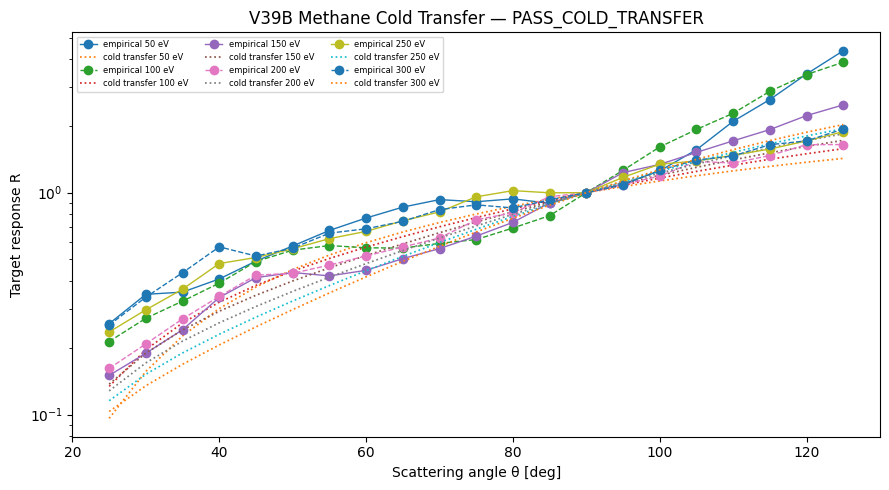

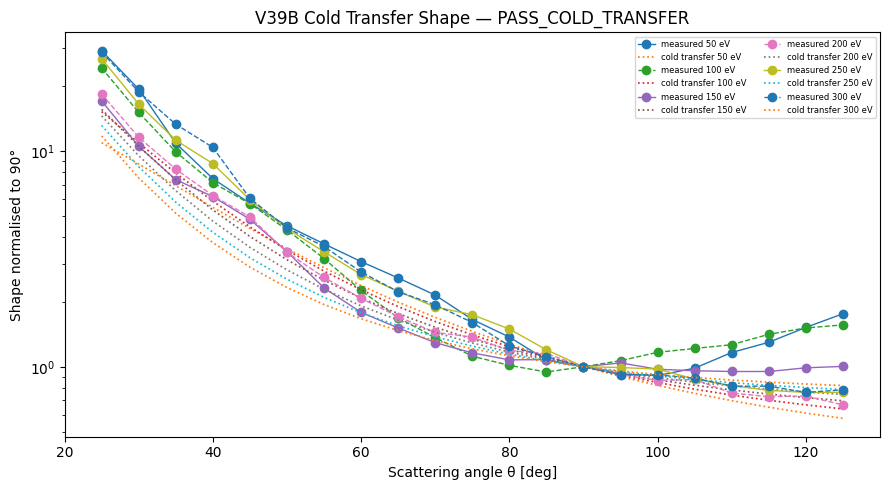

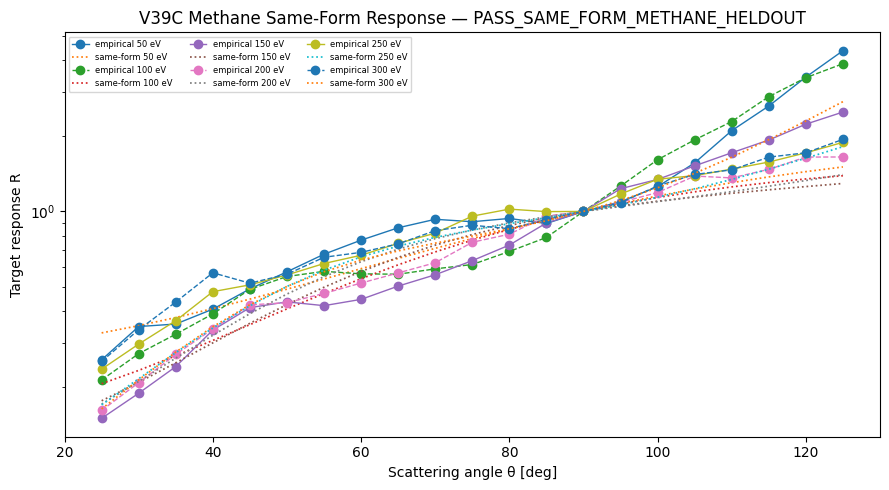

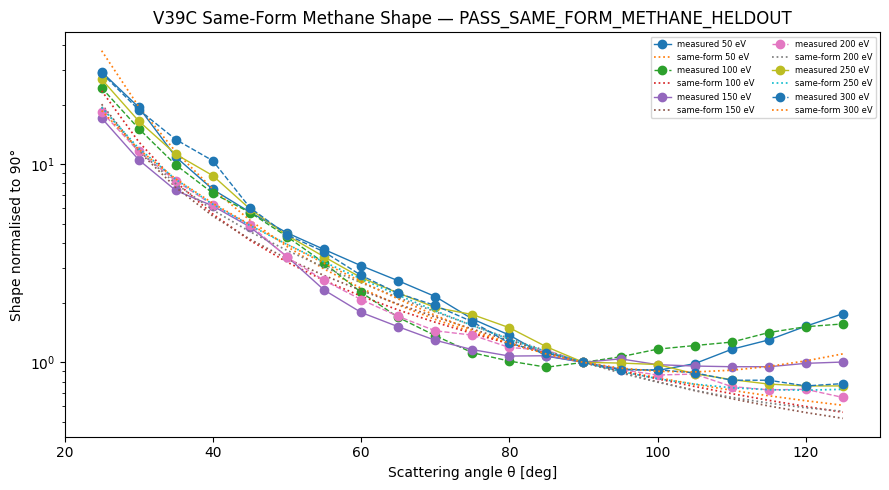

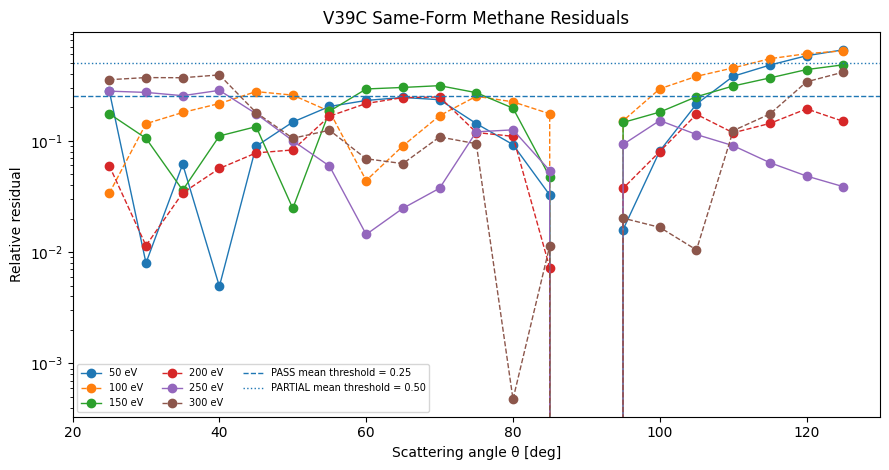

In [10]:
plt.figure(figsize=(9,5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    linestyle='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.required_target_response,marker='o',linestyle=linestyle,linewidth=1,label=f'empirical {E} eV')
    plt.plot(d.theta_deg,d.cold_R_pred,linestyle=':',linewidth=1.25,label=f'cold transfer {E} eV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Target response R'); plt.title(f'V39B Methane Cold Transfer — {cold_label}'); plt.legend(fontsize=6,ncol=3); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    linestyle='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.measured_shape_norm,marker='o',linestyle=linestyle,linewidth=1,label=f'measured {E} eV')
    plt.plot(d.theta_deg,d.cold_pred_shape,linestyle=':',linewidth=1.25,label=f'cold transfer {E} eV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Shape normalised to 90°'); plt.title(f'V39B Cold Transfer Shape — {cold_label}'); plt.legend(fontsize=6,ncol=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    linestyle='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.required_target_response,marker='o',linestyle=linestyle,linewidth=1,label=f'empirical {E} eV')
    plt.plot(d.theta_deg,d.sameform_R_pred,linestyle=':',linewidth=1.25,label=f'same-form {E} eV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Target response R'); plt.title(f'V39C Methane Same-Form Response — {same_label}'); plt.legend(fontsize=6,ncol=3); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    linestyle='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.measured_shape_norm,marker='o',linestyle=linestyle,linewidth=1,label=f'measured {E} eV')
    plt.plot(d.theta_deg,d.sameform_pred_shape,linestyle=':',linewidth=1.25,label=f'same-form {E} eV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Shape normalised to 90°'); plt.title(f'V39C Same-Form Methane Shape — {same_label}'); plt.legend(fontsize=6,ncol=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4.8))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    linestyle='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.sameform_relative_residual,marker='o',linestyle=linestyle,linewidth=1,label=f'{E} eV')
plt.axhline(0.25,linestyle='--',linewidth=1,label='PASS mean threshold = 0.25'); plt.axhline(0.50,linestyle=':',linewidth=1,label='PARTIAL mean threshold = 0.50')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Relative residual'); plt.title('V39C Same-Form Methane Residuals'); plt.legend(fontsize=7,ncol=3); plt.tight_layout(); plt.show()

## Cell 11 — Export outputs

In [11]:
OUT=Path('ecsm_v39_methane_cross_target_replication_outputs')
OUT.mkdir(exist_ok=True)
methane_df.to_csv(OUT/'v39a_locked_methane_dataset.csv',index=False)
diag.to_csv(OUT/'v39_results_full.csv',index=False)
lock_checks.to_csv(OUT/'v39a_lock_checks.csv',index=False)
summary_metrics.to_csv(OUT/'v39_summary_metrics.csv',index=False)
param_compare.to_csv(OUT/'v39d_parameter_comparison.csv',index=False)
criteria_df.to_csv(OUT/'v39_criteria.csv',index=False)
with open(OUT/'run_summary_v39.json','w') as f: json.dump(run_summary,f,indent=2)
zip_path=Path('ecsm_v39_methane_cross_target_replication_outputs.zip')
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
    for item in OUT.iterdir(): z.write(item,arcname=item.name)
print('Exported output folder:', OUT)
print('Exported ZIP:', zip_path)

Exported output folder: ecsm_v39_methane_cross_target_replication_outputs
Exported ZIP: ecsm_v39_methane_cross_target_replication_outputs.zip


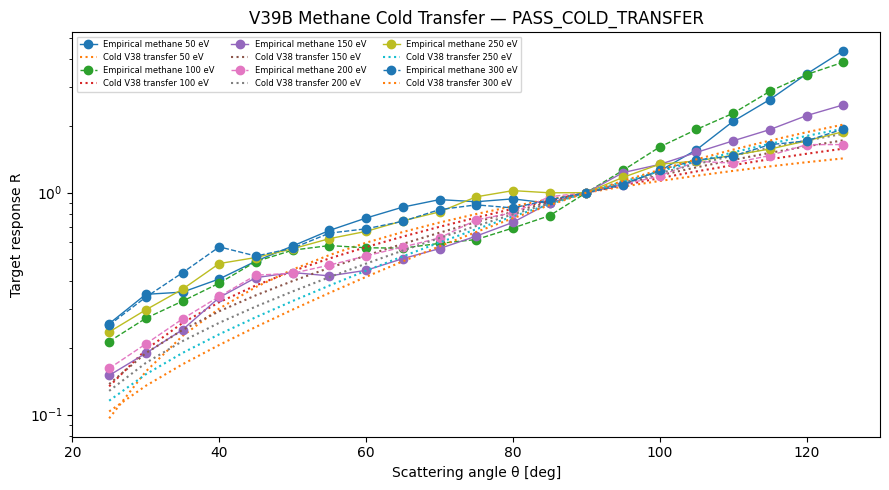

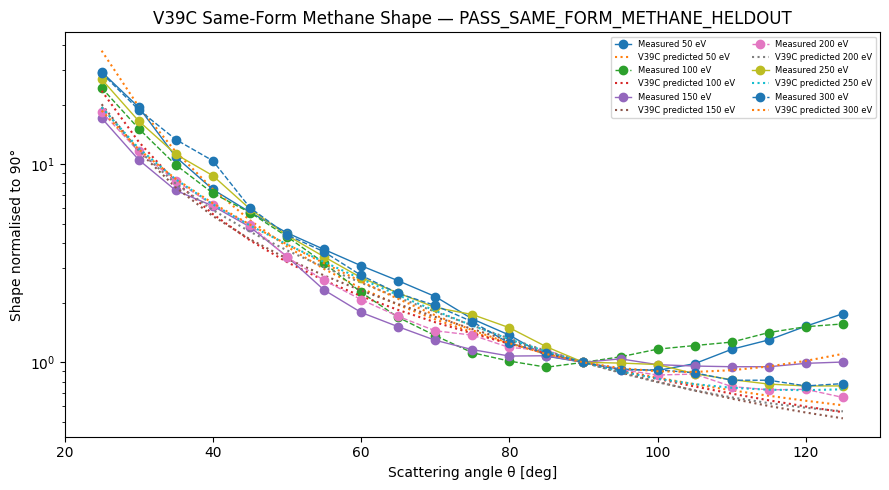

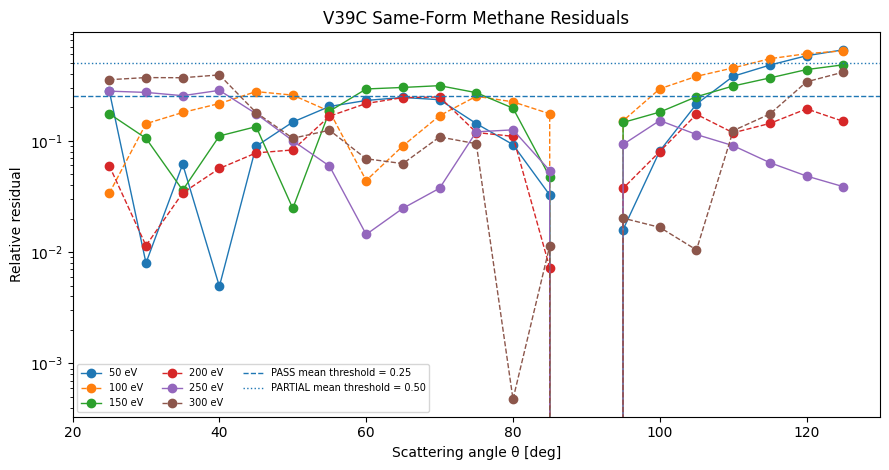

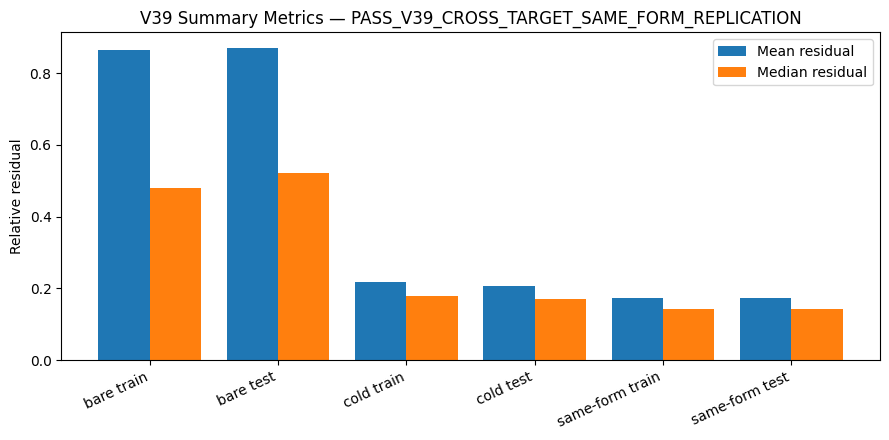

Exported V39 paper figures:
v39_paper_figures/fig_v39b_cold_transfer_target_response.png
v39_paper_figures/fig_v39c_same_form_shape_vs_measured.png
v39_paper_figures/fig_v39c_same_form_residuals.png
v39_paper_figures/fig_v39_summary_metrics.png

ZIP file:
v39_paper_figures.zip


In [12]:
# ============================================================
# V39 — Export paper figures only
# Creates clean PNG figures + one ZIP for paper upload
# ============================================================

from pathlib import Path
import zipfile
import matplotlib.pyplot as plt

FIG_OUT = Path("v39_paper_figures")
FIG_OUT.mkdir(exist_ok=True)

fig_files = []

# ------------------------------------------------------------
# Figure 1 — V39B cold-transfer target response
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

for E, d in diag.groupby("beam_energy_eV", sort=True):
    linestyle = "-" if E in TRAIN_E else "--"

    plt.plot(
        d.theta_deg,
        d.required_target_response,
        marker="o",
        linestyle=linestyle,
        linewidth=1,
        label=f"Empirical methane {int(E)} eV"
    )

    plt.plot(
        d.theta_deg,
        d.cold_R_pred,
        linestyle=":",
        linewidth=1.5,
        label=f"Cold V38 transfer {int(E)} eV"
    )

plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Target response R")
plt.title(f"V39B Methane Cold Transfer — {cold_label}")
plt.legend(fontsize=6, ncol=3)
plt.tight_layout()

fig1 = FIG_OUT / "fig_v39b_cold_transfer_target_response.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()
fig_files.append(fig1)


# ------------------------------------------------------------
# Figure 2 — V39C same-form methane predicted shape
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

for E, d in diag.groupby("beam_energy_eV", sort=True):
    linestyle = "-" if E in TRAIN_E else "--"

    plt.plot(
        d.theta_deg,
        d.measured_shape_norm,
        marker="o",
        linestyle=linestyle,
        linewidth=1,
        label=f"Measured {int(E)} eV"
    )

    plt.plot(
        d.theta_deg,
        d.sameform_pred_shape,
        linestyle=":",
        linewidth=1.5,
        label=f"V39C predicted {int(E)} eV"
    )

plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Shape normalised to 90°")
plt.title(f"V39C Same-Form Methane Shape — {same_label}")
plt.legend(fontsize=6, ncol=2)
plt.tight_layout()

fig2 = FIG_OUT / "fig_v39c_same_form_shape_vs_measured.png"
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()
fig_files.append(fig2)


# ------------------------------------------------------------
# Figure 3 — V39C same-form residuals
# ------------------------------------------------------------
plt.figure(figsize=(9, 4.8))

for E, d in diag.groupby("beam_energy_eV", sort=True):
    linestyle = "-" if E in TRAIN_E else "--"

    plt.plot(
        d.theta_deg,
        d.sameform_relative_residual,
        marker="o",
        linestyle=linestyle,
        linewidth=1,
        label=f"{int(E)} eV"
    )

plt.axhline(
    0.25,
    linestyle="--",
    linewidth=1,
    label="PASS mean threshold = 0.25"
)

plt.axhline(
    0.50,
    linestyle=":",
    linewidth=1,
    label="PARTIAL mean threshold = 0.50"
)

plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Relative residual")
plt.title("V39C Same-Form Methane Residuals")
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()

fig3 = FIG_OUT / "fig_v39c_same_form_residuals.png"
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()
fig_files.append(fig3)


# ------------------------------------------------------------
# Figure 4 — Summary metrics
# ------------------------------------------------------------
plt.figure(figsize=(9, 4.5))

x = range(len(summary_metrics))

plt.bar(
    [i - 0.2 for i in x],
    summary_metrics["mean"],
    width=0.4,
    label="Mean residual"
)

plt.bar(
    [i + 0.2 for i in x],
    summary_metrics["median"],
    width=0.4,
    label="Median residual"
)

plt.xticks(
    list(x),
    summary_metrics["case"],
    rotation=25,
    ha="right"
)

plt.ylabel("Relative residual")
plt.title(f"V39 Summary Metrics — {final_label}")
plt.legend()
plt.tight_layout()

fig4 = FIG_OUT / "fig_v39_summary_metrics.png"
plt.savefig(fig4, dpi=300, bbox_inches="tight")
plt.show()
fig_files.append(fig4)


# ------------------------------------------------------------
# ZIP export
# ------------------------------------------------------------
zip_path = Path("v39_paper_figures.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in fig_files:
        z.write(p, arcname=p.name)

print("Exported V39 paper figures:")
for p in fig_files:
    print(p)

print()
print("ZIP file:")
print(zip_path)